In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('new_insurance_data.csv')
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(1287, 13)

In [10]:
col = df.columns
col

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

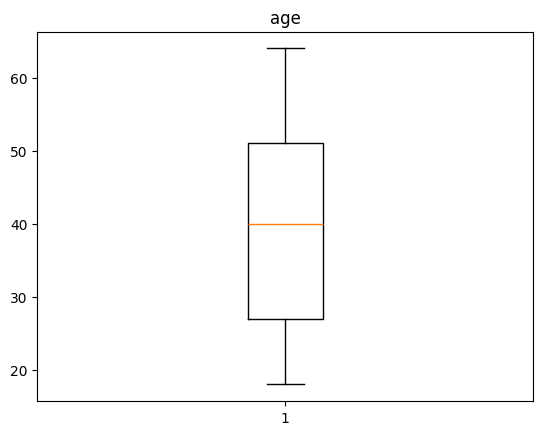

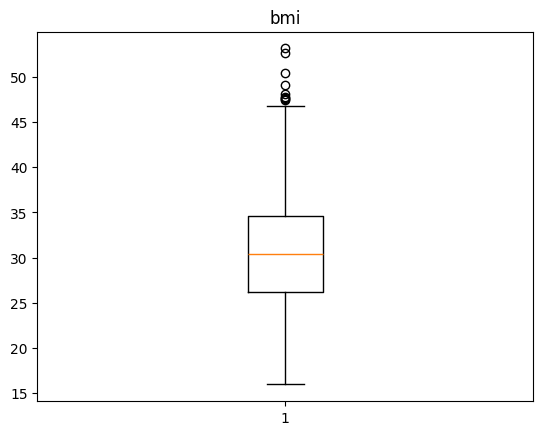

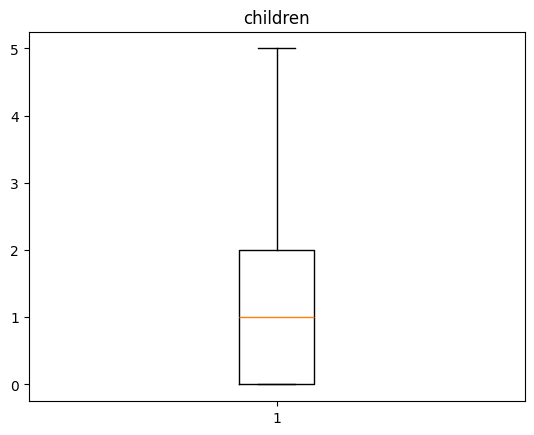

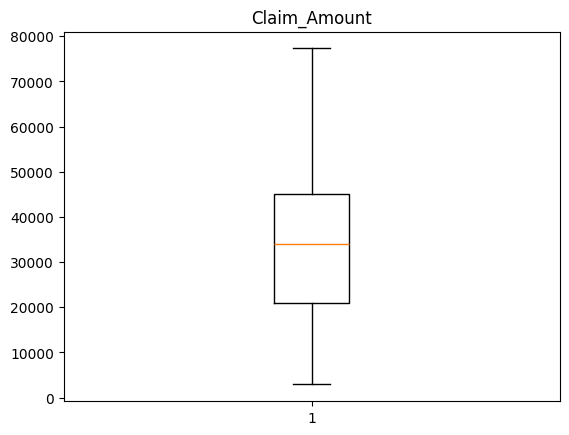

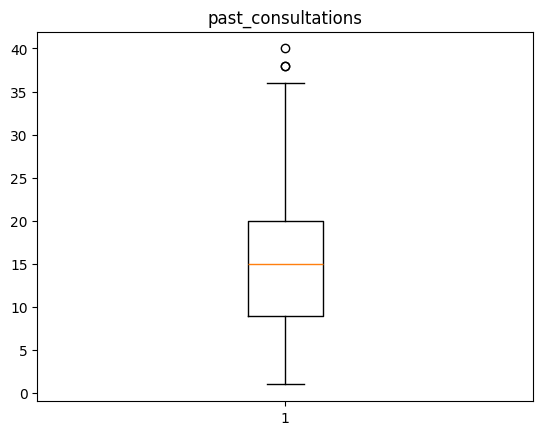

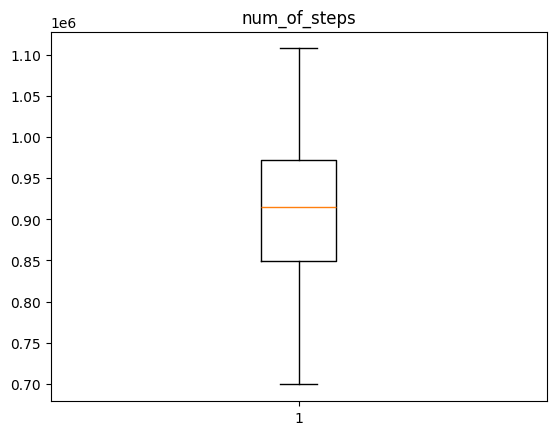

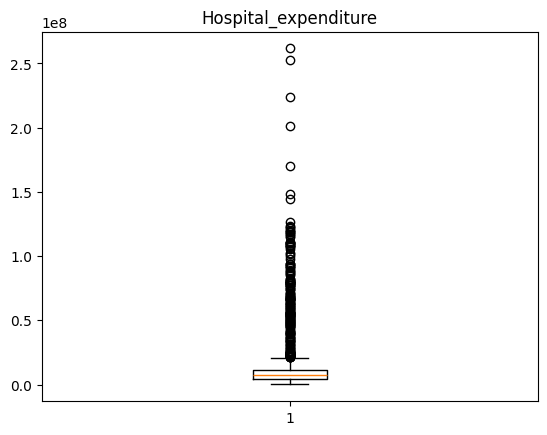

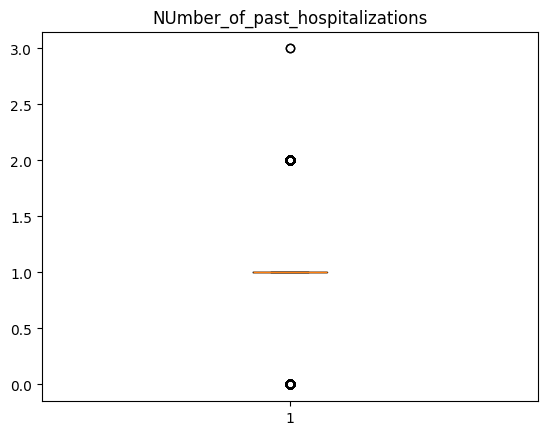

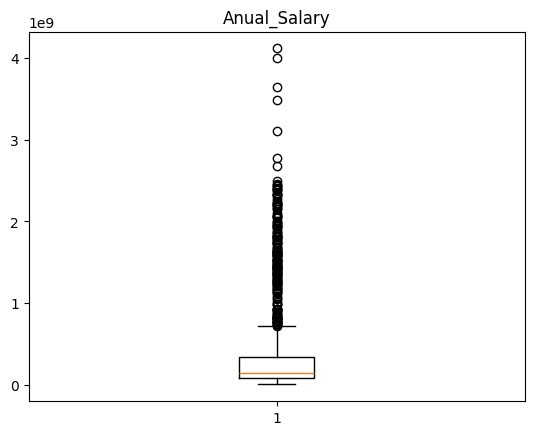

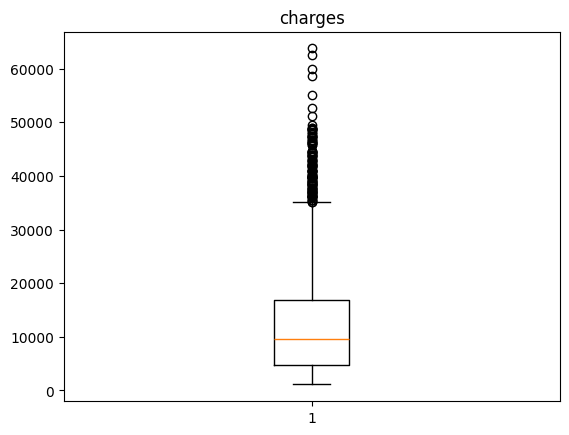

In [12]:
for i in col:
    if df[i].dtype != 'O':
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [13]:
for i in col:
    if df[i].dtype != 'O':
        q1 = df[i].quantile(.25)
        q3 = df[i].quantile(.75)

        iqr = q3 - q1

        lb = q1 - (1.5*iqr)
        ub = q3 + (1.5*iqr)

        df = df[(df[i] >= lb) & (df[i] <= ub)]

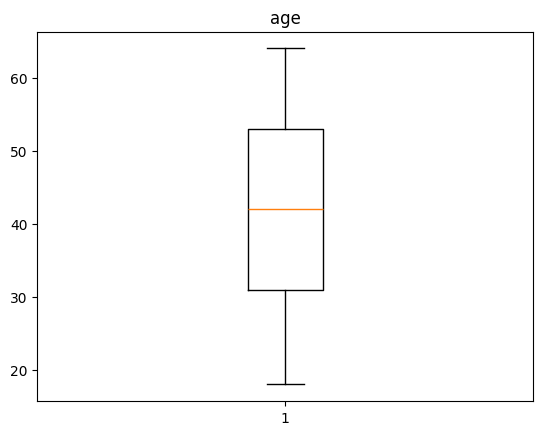

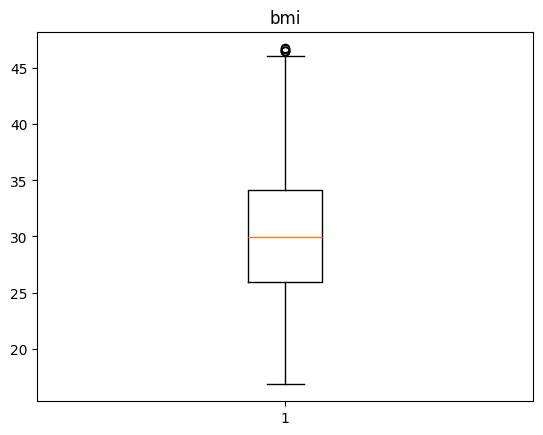

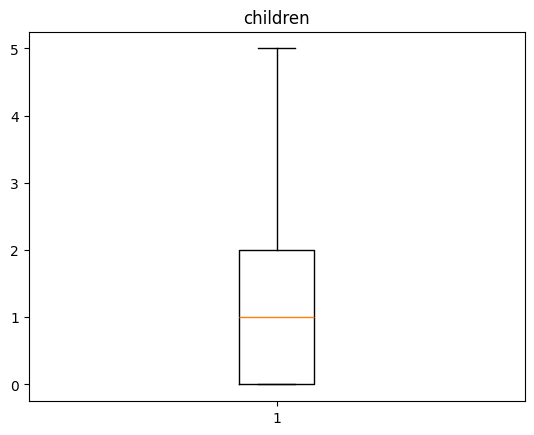

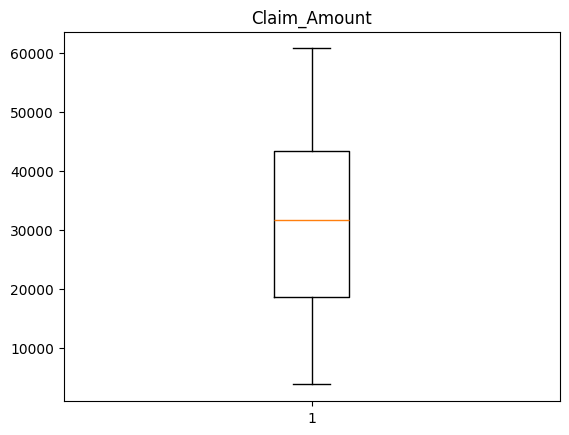

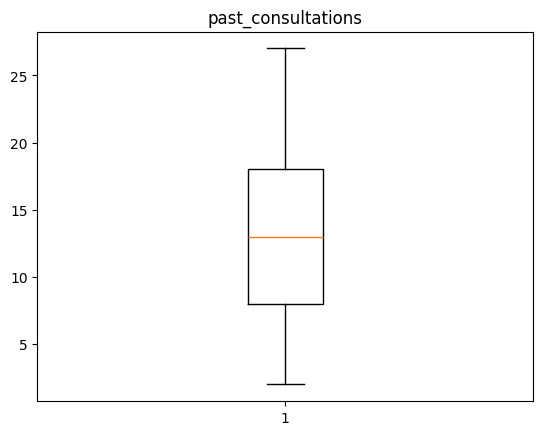

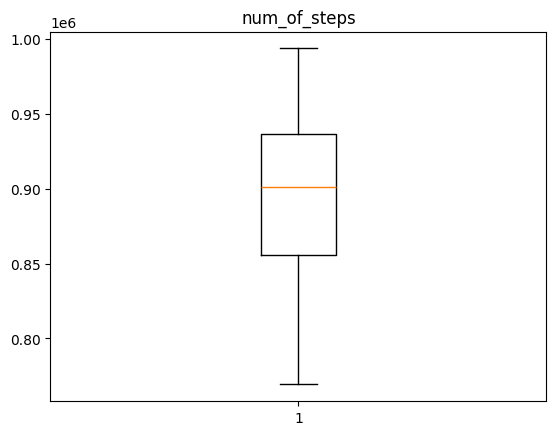

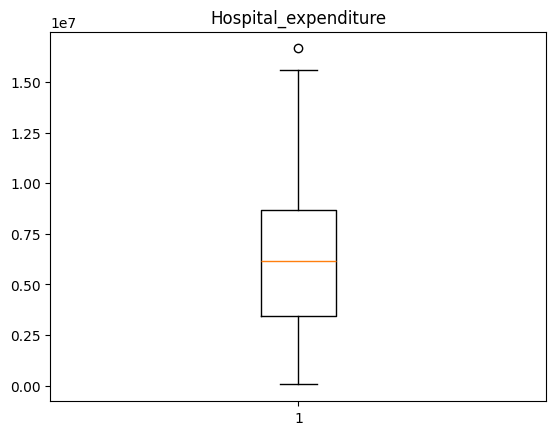

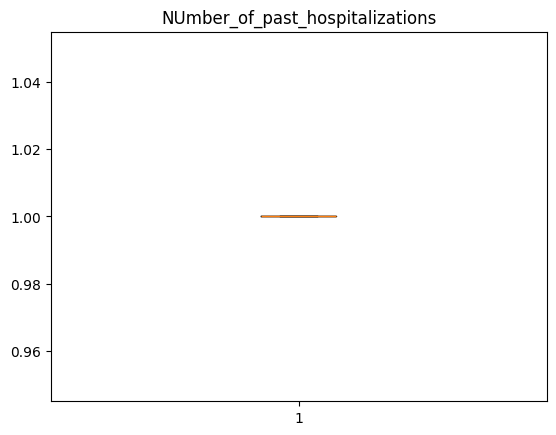

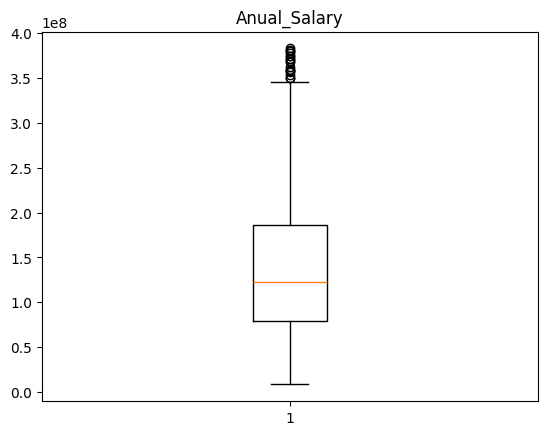

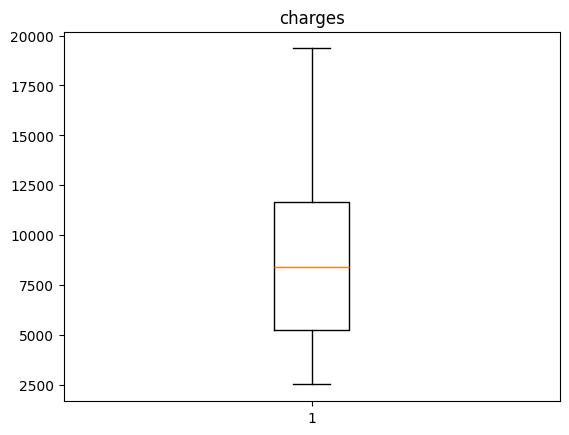

In [17]:
for i in col:
    if df[i].dtype != "O":
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [21]:
for i in col:
    if df[i].dtype == 'O':
        df[i] = le.fit_transform(df[i])

In [23]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,1,27.550,0.0,0,39148.95495,10.0,780652.0,8.614147e+06,1.0,54526009.33,1,2523.16950
152,22.0,0,20.235,0.0,0,41547.52536,13.0,802627.0,2.491594e+05,1.0,16718473.13,1,2527.81865
153,25.0,1,35.625,0.0,0,39660.60193,12.0,770773.0,3.043323e+06,1.0,48526941.68,1,2534.39375
154,20.0,1,31.130,2.0,0,16032.87148,7.0,769255.0,1.599069e+06,1.0,24412621.85,2,2566.47070
155,21.0,0,17.400,1.0,0,31090.98977,21.0,778769.0,3.015365e+06,1.0,58535788.80,3,2585.26900


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [29]:
x = df.iloc[:, :-1]

In [30]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
151,25.0,1,27.550,0.0,0,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07,1
152,22.0,0,20.235,0.0,0,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07,1
153,25.0,1,35.625,0.0,0,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07,1
154,20.0,1,31.130,2.0,0,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07,2
155,21.0,0,17.400,1.0,0,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1036,43.0,1,20.130,2.0,1,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,2
1041,24.0,0,27.600,0.0,0,27184.27803,9.0,980010.0,1.266673e+07,1.0,3.743228e+08,3
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3


In [31]:
y = df.iloc[:, -1]

In [32]:
y

151      2523.16950
152      2527.81865
153      2534.39375
154      2566.47070
155      2585.26900
           ...     
1036    18767.73770
1041    18955.22017
1046    19107.77960
1048    19199.94400
1050    19350.36890
Name: charges, Length: 851, dtype: float64

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= .3, random_state= 42)

model = LinearRegression()

In [34]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred = model.predict(x_test)

In [38]:
table = pd.DataFrame(columns=['actual charges', 'pred charges'])
table['actual charges'] = y_test
table['pred charges'] = y_pred
table

,actual charges,pred charges
218,3353.47030,4354.914132
486,6753.03800,6821.265464
839,11884.04858,10326.607590
980,15006.57945,15270.988457
568,7985.81500,7815.627114
...,...,...
234,3556.92230,4504.478612
320,4562.84210,3669.674429
319,4561.18850,4505.150834
179,2842.76075,2892.236289


<Axes: ylabel='charges'>

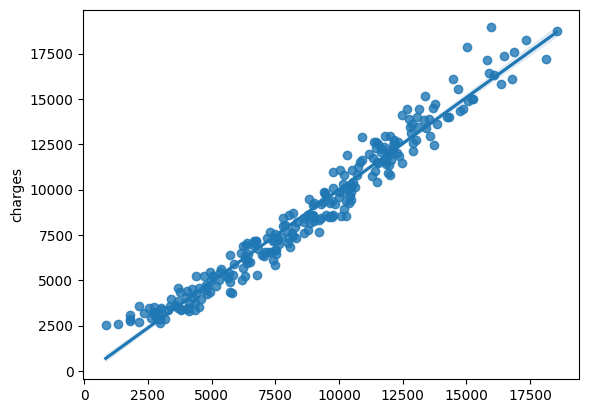

In [40]:
sns.regplot(x = y_pred, y = y_test)